In [9]:
import pandas as pd
import time
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("dark")

import tiktoken
import ollama
from datasets import load_dataset
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS

In [10]:
df_rag = load_dataset("neural-bridge/rag-dataset-12000")
df1 = df_rag['train'].to_pandas()
df2 = df_rag['test'].to_pandas()
df_rag = pd.concat([df1, df2], axis=0)
df_rag.head(2)

,context,question,answer
0,Caption: Tasmanian berry grower Nic Hansen sho...,What is the Berry Export Summary 2028 and what...,The Berry Export Summary 2028 is a dedicated e...
1,RWSN Collaborations\nSouthern Africa Self-supp...,What are some of the benefits reported from ha...,Benefits reported from having access to Self-s...


In [11]:
indx = 9
print("Context: \n")
print(df_rag["context"].iloc[indx])

print("\nQuestion: \n")
print(df_rag["question"].iloc[indx])


Context: 

5 Great Podcasts on Love and Relationships/
As much as you’d like to think that you can handle your love and relationship problems on your own like a champ, it never hurts to get advice (or even an entirely different perspective) from people who have already been there, done that, and set up an appropriately themed podcast to talk about it.
But with the sheer number of love and relationship podcasts out there, you just can’t help but wonder: Which ones among them should you be listening to?
And frankly, does it even matter?
Seriously, how many different ways can people actually talk about such a universal and all-encompassing emotion as love?
As it turns out, quite a lot — and these five love and relationship podcasts are among the best and most unique ones out there.
Love Is Like A Plant with Sarah May Bates and Ellen Huerta
What do you get when you combine two experts on love and heartbreak in one podcast? An informative and in-depth conversation about planting the seeds o

In [12]:
def count_tokens(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    tokens = encoding.encode(text)
    return len(tokens)

In [13]:
df_rag['token'] = df_rag['context'].apply(count_tokens)
df_rag.head(2)

,context,question,answer,token
0,Caption: Tasmanian berry grower Nic Hansen sho...,What is the Berry Export Summary 2028 and what...,The Berry Export Summary 2028 is a dedicated e...,678
1,RWSN Collaborations\nSouthern Africa Self-supp...,What are some of the benefits reported from ha...,Benefits reported from having access to Self-s...,943


In [14]:
df_rag = df_rag[~df_rag['question'].isna()]
df_rag = df_rag[df_rag['token'] < 350]
df_rag = df_rag.sample(1000)
len(df_rag)

1000

In [15]:
contexts = list(df_rag["context"])
questions = list(df_rag["question"])

In [16]:
df_rag.to_csv("vector_dbs_2/rag_sample_1000.csv", index=False)

In [17]:
embedding_models = {
    "nomic-embed-text": "nomic",
    "mxbai-embed-large": "mxbai",
    "jina/jina-embeddings-v2-base-en": "jina", 
    "all-minilm:33m": "minilm",
    "snowflake-arctic-embed2": "snowflake",
    "bge-large": "bge",
    "granite-embedding:278m": "granite"
}


In [18]:
# llms = [
#         "nomic-embed-text",
#         "nomic-ai/nomic-embed-text-v1.5",
#         "mxbai-embed-large",
#         "mixedbread-ai/mxbai-embed-large-v1",
#         "jinaai/jina-embeddings-v3",
#         "snowflake-arctic-embed",
#         "Snowflake/snowflake-arctic-embed-l",
#         "sentence-transformers/all-MiniLM-l6-v2",
#         "sentence-transformers/all-MiniLM-l12-v2",
#         "sentence-transformers/all-mpnet-base-v2" 
#         "BAAI/bge-large-en-v1.5",
#         "nvidia/NV-Embed-v2",
#         "Alibaba-NLP/gte-Qwen2-7B-instruct",
#         "Salesforce/SFR-Embedding-2_R"
#         "Alibaba-NLP/gte-large-en-v1.5"
#         "thenlper/gte-large",
#         "intfloat/e5-large-v2",
# ]

In [19]:
results = []

for model, name in embedding_models.items():
    metadata = ollama.show(model)

    nparams = metadata['details']['parameter_size']
    family = metadata['details']['family']
    context_len = metadata['model_info'][family + ".context_length"] 
    emb_size = metadata['model_info'][family + ".embedding_length"]

    results.append({
        "Model Name": name,
        "Model ID": model,
        "Context Length": context_len,
        "Embedding Size": emb_size,
        "Parameter Size": nparams,
        "Family": family
    })

df_models = pd.DataFrame(results)
df_models.head(10)

,Model Name,Model ID,Context Length,Embedding Size,Parameter Size,Family
0,nomic,nomic-embed-text,2048,768,137M,nomic-bert
1,mxbai,mxbai-embed-large,512,1024,334M,bert
2,jina,jina/jina-embeddings-v2-base-en,8192,768,136.78M,jina-bert-v2
3,minilm,all-minilm:33m,512,384,33M,bert
4,snowflake,snowflake-arctic-embed2,8192,1024,566.70M,bert
5,bge,bge-large,512,1024,334.09M,bert
6,granite,granite-embedding:278m,512,768,277.45M,bert


In [20]:
processing_times = []

for llm, name in embedding_models.items():
    ret_docs = []

    llm_embed = OllamaEmbeddings(model=llm)

    start_time = time.time()
    db = FAISS.from_texts(contexts, llm_embed)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Embedding model {name}, Elapsed time: {elapsed_time:.2f} seconds")

    processing_times.append({
        "Model Name": name,
        "Model ID": llm,
        "Processing Time (s)": elapsed_time
    })

    db_name = "vector_dbs_2/" + name
    db.save_local(db_name)


df_times = pd.DataFrame(processing_times)


Embedding model nomic, Elapsed time: 75.51 seconds
Embedding model mxbai, Elapsed time: 161.65 seconds
Embedding model jina, Elapsed time: 115.74 seconds
Embedding model minilm, Elapsed time: 114.16 seconds
Embedding model snowflake, Elapsed time: 260.88 seconds
Embedding model bge, Elapsed time: 166.45 seconds
Embedding model granite, Elapsed time: 130.00 seconds


In [21]:
!ls vector_dbs_2/

bge                 jina                mxbai               rag_sample_1000.csv
granite             minilm              nomic               snowflake


In [2]:
!ls vector_dbs_2/bge/

index.faiss index.pkl


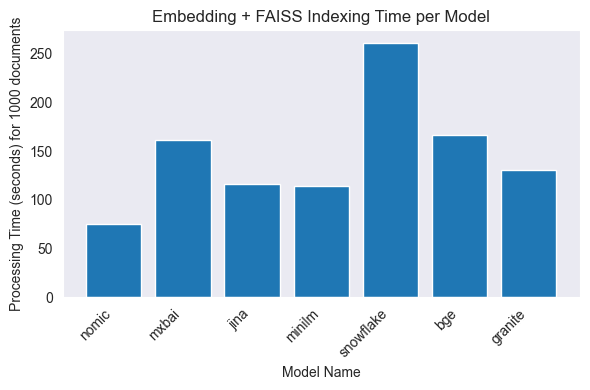

In [23]:
plt.figure(figsize=(6, 4))
plt.bar(df_times['Model Name'], df_times['Processing Time (s)'])
plt.xlabel("Model Name")
plt.ylabel("Processing Time (seconds) for 1000 documents")
plt.title("Embedding + FAISS Indexing Time per Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_ret = pd.DataFrame()
df_ret['question'] = df_rag['question']
#df_ret['context_gt'] = df_rag['context']

processing_times = []

for llm, name in list(embedding_models.items()):
    ret_docs = []
        
    llm_embed = OllamaEmbeddings(model=llm)  
    db_name = "vector_dbs_2/" + name
    db = FAISS.load_local(db_name, llm_embed, allow_dangerous_deserialization=True)
    retriever = db.as_retriever(search_kwargs={"k": 1})
    
    start_time = time.time()
    for que in df_ret['question']:
        ret_doc = retriever.invoke(que)
        ret_doc = ret_doc[0].page_content
        ret_docs.append(ret_doc)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Embedding model {name}, Elapsed time: {elapsed_time:.2f} seconds")

    processing_times.append({
        "Model Name": name,
        "Model ID": llm,
        "Processing Time (s)": elapsed_time
    })
    df_ret[name] = ret_docs

df_times = pd.DataFrame(processing_times)


Embedding model nomic, Elapsed time: 46.76 seconds
Embedding model mxbai, Elapsed time: 45.40 seconds
Embedding model jina, Elapsed time: 47.45 seconds
Embedding model minilm, Elapsed time: 27.96 seconds
Embedding model snowflake, Elapsed time: 128.28 seconds
Embedding model bge, Elapsed time: 78.83 seconds
Embedding model granite, Elapsed time: 86.10 seconds


In [25]:
df_ret.head()

,question,nomic,mxbai,jina,minilm,snowflake,bge,granite
3843,What is the premise of Whitley Strieber's upco...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...
4925,Why did Freedom Industries file for bankruptcy...,"CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo..."
3625,How can one save the images of the '50 Good Ac...,50 Good Acrylic Paint\n– Welcome to help my pe...,50 Good Acrylic Paint\n– Welcome to help my pe...,50 Good Acrylic Paint\n– Welcome to help my pe...,50 Good Acrylic Paint\n– Welcome to help my pe...,50 Good Acrylic Paint\n– Welcome to help my pe...,50 Good Acrylic Paint\n– Welcome to help my pe...,50 Good Acrylic Paint\n– Welcome to help my pe...
3169,What is the alcohol content of Toscana Igt Ros...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...,Lorenzo C\nDenomination: Toscana Igt Rosso “Lo...
326,"Who is responsible for the content, products, ...",- The content available through this website i...,- The views expressed on this site are entirel...,- The content available through this website i...,- The content available through this website i...,- The content available through this website i...,- The content available through this website i...,- The content available through this website i...


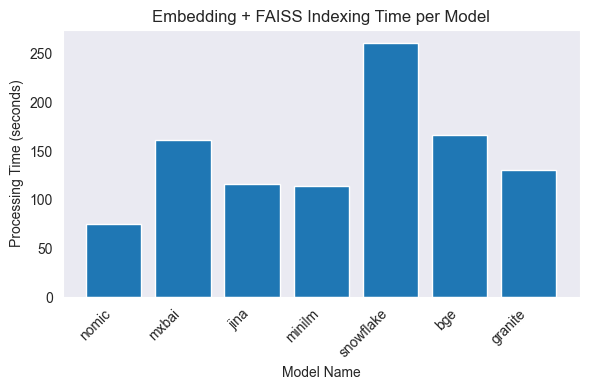

In [26]:
# Plotting
plt.figure(figsize=(6, 4))
plt.bar(df_times['Model Name'], df_times['Processing Time (s)'])
plt.xlabel("Model Name")
plt.ylabel("Processing Time (seconds)")
plt.title("Embedding + FAISS Indexing Time per Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [27]:
def most_common(lst):
    count = Counter(lst)
    most_common_val, freq = count.most_common(1)[0]
    if list(count.values()).count(freq) > 1:  # Check for ties
        return pd.Series([None, None])  # tie  - return None
    return pd.Series([most_common_val, freq])


In [28]:
df_ret[['voting_winner', 'voting_count']] = df_ret.apply(lambda row: most_common(row), axis=1)
df_ret.head(2)

,question,nomic,mxbai,jina,minilm,snowflake,bge,granite,voting_winner,voting_count
3843,What is the premise of Whitley Strieber's upco...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,TMZ.com is running a report today that sci-fi ...,7.0
4925,Why did Freedom Industries file for bankruptcy...,"CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...","CHARLESTON, W.Va. — Those owed money by Freedo...",7.0


In [29]:
#df_ret = df_ret.dropna(subset=['voting_winner'])

correct_counts = {}
for model in df_ret.columns[1:-2]:  
    correct_counts[model] = (df_ret[model] == df_ret['voting_winner']).sum()

df_perf = pd.DataFrame(list(correct_counts.items()), columns=['Model', 'Correct_Counts'])
df_perf['Percentage_Correct'] = 100*df_perf['Correct_Counts']/len(df_ret)
df_perf['Percentage_Correct'] = df_perf['Percentage_Correct'].apply(lambda x:round(x,2))

df_perf = df_perf.sort_values(by='Correct_Counts', ascending=False)

df_perf.head(10)

,Model,Correct_Counts,Percentage_Correct
5,bge,957,95.7
1,mxbai,948,94.8
4,snowflake,931,93.1
6,granite,927,92.7
2,jina,915,91.5
0,nomic,914,91.4
3,minilm,868,86.8


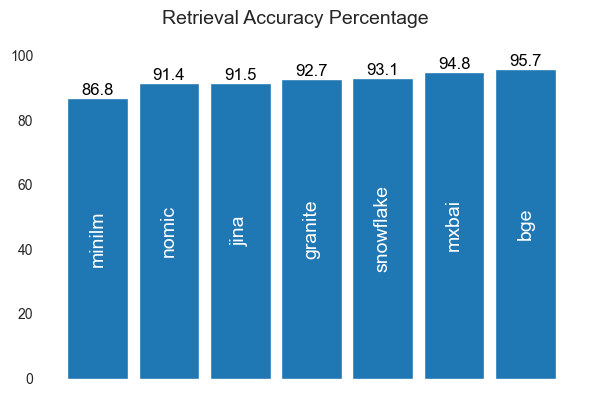

In [35]:
df_perf = df_perf.sort_values('Percentage_Correct', ascending=True)
df_perf = df_perf[df_perf['Percentage_Correct'] != 100.0]


fig, ax = plt.subplots(figsize=(6, 4), facecolor='none', edgecolor='none')
fig.patch.set_alpha(0)

bars = ax.bar(df_perf['Model'], df_perf['Percentage_Correct'], width=0.85)

ax.set_xticks([])  # Hide tick marks

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Value label to the right of the bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height}', 
            ha='center', va='bottom', fontsize=12, color='black')

# Model label inside the bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height / 2, df_perf['Model'].iloc[i], 
            ha='center', va='center', fontsize=14, color='white', rotation=90)

ax.set_ylabel('')
ax.patch.set_alpha(0)

plt.suptitle("Retrieval Accuracy Percentage", fontsize=14)
plt.tight_layout()
#plt.savefig('retrieval_accuracy_without_gt.png', dpi=300, bbox_inches='tight', transparent=True)



In [4]:
df_models.head(10)

NameError: name 'df_models' is not defined

In [34]:
exit("Stop here....")